In [ ]:
library(ggplot2)
library(tidyverse)
library(gridExtra)
library(GGally)
library(plotly)
library(corrplot)
library(reshape2)
library(FactoMineR) 
library(factoextra)
library(glmnet) 
library(ggfortify)
library(pROC)
library(ROCR)
library(GGally)
library(dplyr)

In [52]:
data<-read.csv("new_games.csv",header = TRUE)

In [53]:
summary(data)

     AppID             Name           Release.date       Estimated.owners  
 Min.   :     10   Length:122611      Length:122611      Length:122611     
 1st Qu.:1063175   Class :character   Class :character   Class :character  
 Median :1907380   Mode  :character   Mode  :character   Mode  :character  
 Mean   :1985386                                                           
 3rd Qu.:2869560                                                           
 Max.   :4264350                                                           
                                                                           
    Peak.CCU          Required.age         Price             Discount     
 Min.   :0.000e+00   Min.   : 0.0000   Min.   :   0.000   Min.   :  0.00  
 1st Qu.:0.000e+00   1st Qu.: 0.0000   1st Qu.:   0.550   1st Qu.:  0.00  
 Median :0.000e+00   Median : 0.0000   Median :   2.240   Median :  0.00  
 Mean   :5.459e+01   Mean   : 0.1676   Mean   :   4.765   Mean   : 18.35  
 3rd Qu.:0.000e+0

# Conversion des variables lues en tant que quantitatives en qualitatives

Il me semble que les variables ci-dessous sont plutôt des variables qualitatives donc je les ai converti.

In [ ]:

data[,"Estimated.owners"]=as.factor(data[,"Estimated.owners"])
data[,"Required.age"]=as.factor(data[,"Required.age"])
data[,"Windows"]=as.factor(data[,"Windows"])
data[,"Mac"]=as.factor(data[,"Mac"])
data[,"Linux"]=as.factor(data[,"Linux"])


summary(data)

       

#  Suppresion de variables inutiles à l'exploration des données

J'ai choisi de supprimer plusieurs variable qui à mon avis ne seraient pas pertinente lors de l'analyse de certaine donnée. J'ai aussi supprimé la variable Movies car elle ne contennait que des NA.

In [55]:
data1 <- data %>% select(-c(AppID, About.the.game, Reviews,Movies,Header.image,Support.email,Support.url,Notes,Metacritic.url,Screenshots))

In [56]:
head(data1)

,Name,Release.date,Estimated.owners,Peak.CCU,Required.age,Price,Discount,DLC.count,Supported.languages,Full.audio.languages,⋯,Recommendations,Average.playtime.forever,Average.playtime.two.weeks,Median.playtime.forever,Median.playtime.two.weeks,Developers,Publishers,Categories,Genres,Tags
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<int>,<chr>,<chr>,⋯,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,[],[],⋯,0,0,0,0,0,,,,,
2,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,['English'],[],⋯,231,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,Family Sharing",Adventure,"Adventure,Visual Novel,Anime,Cute"
3,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"['English', 'French', 'German', 'Russian']",[],⋯,0,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Object,2D,Colorful,Stylized,Logic,Mystery,Atmospheric,Family Friendly,PvE,Tutorial,Singleplayer,Tabletop"
4,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,['Korean'],['Korean'],⋯,0,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",
5,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,['English'],['English'],⋯,0,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Family Sharing","Action,Early Access",
6,Agony VR,"Apr 5, 2023",0 - 20000,0,0,13.99,0,0,"['English', 'French', 'Italian', 'German', 'Spanish - Spain', 'Polish', 'Portuguese - Portugal', 'Russian', 'Turkish']","['English', 'Turkish']",⋯,0,0,0,0,0,Ignibit,"Ignibit,Madmind Studio","Single-player,Tracked Controller Support,VR Only,Family Sharing","Action,Adventure",


### Etude sur la variable supported.language

In [57]:
head(data1[,"Supported.languages"])

[1] "[]"                                                                                                                    
[2] "['English']"                                                                                                           
[3] "['English', 'French', 'German', 'Russian']"                                                                            
[4] "['Korean']"                                                                                                            
[5] "['English']"                                                                                                           
[6] "['English', 'French', 'Italian', 'German', 'Spanish - Spain', 'Polish', 'Portuguese - Portugal', 'Russian', 'Turkish']"

Plutôt que de garder la variable supported.languages qui ne contient que des chaines de caractère. On peut plutôt étudier le nombre de jeu supporté par chaque langue (première cellule) ou par jeux le nombre de langue supporté et est ce que ça à une influence sur la note du jeu ou autre chose (deuxième cellule).

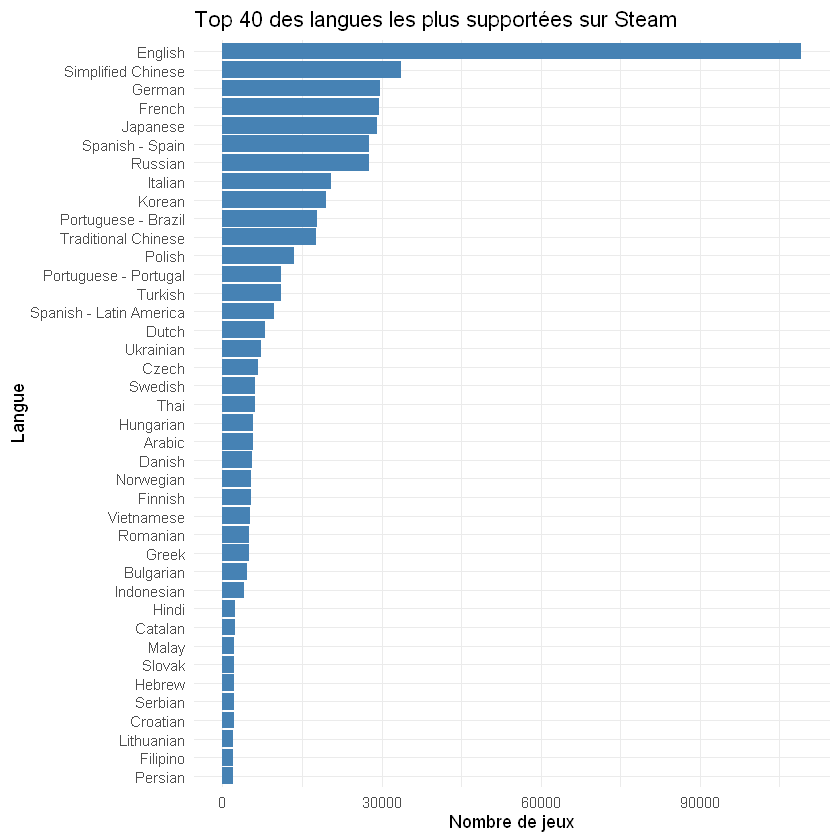

In [58]:
stats_langues <- data1 %>%
  # 1. On nettoie les symboles parasites [ ] ' "
  mutate(clean_txt = str_remove_all(Supported.languages, "\\[|\\]|'|\"")) %>%
  # 2. On "éclate" les listes : si un jeu a 3 langues, ça crée 3 lignes
  separate_rows(clean_txt, sep = ",\\s*") %>%
  # 3. On compte combien de fois chaque langue apparaît
  count(clean_txt, sort = TRUE) %>%
  # 4. On garde les 50 premières (en enlevant les vides)
  filter(clean_txt != "" & !is.na(clean_txt)) %>%
  head(40)


ggplot(stats_langues, aes(x = reorder(clean_txt, n), y = n)) +
  geom_col(fill = "steelblue") +
  coord_flip() + # Pour mettre les noms à l'horizontale 
  labs(
    title = "Top 40 des langues les plus supportées sur Steam",
    x = "Langue",
    y = "Nombre de jeux"
  ) +
  theme_minimal()

In [59]:
data1 <- data1 |>
  mutate(nb_language_supported = case_when(
      Supported.languages == "[]" ~ 0,          # Si c'est une liste vide Steam [] -> 0
    TRUE ~ str_count(Supported.languages, ",") + 1  
  ))
head(data1$nb_language_supported)

[1] 0 1 4 1 1 9

### Etude des variables developers et publishers

Je propose de faire de même pour les variables developers et publishers: c'est à dire de regarder si la note du jeu a un lien avec sont studio de développement et son publieur. J'ai converti les chaines de caractères en minuscule et envelevé les points car dans un premier temps j'ai vu que certains chaines de caractère étaient la même mais juste en majuscule .

In [ ]:

# 1. On définit la liste des suffixes à nettoyer (le "bruit")
# Tu peux en ajouter d'autres ici si tu en vois de nouveaux dans tes données
bruit_juridique <- c("LTD", "INC", "LLC", "CORP", "CO", "SA", "SAS", "GMBH", "KK", "SL", "AS")

# On crée le "pattern" de recherche (Regex) : 
# Il cherche ces mots uniquement à la fin de la ligne (d'où le $)
pattern_bruit <- paste0("\\s*\\b(", paste(bruit_juridique, collapse = "|"), ")\\b[. ]*$")

# 2. Traitement du dataset
stat_dev_clean <- data1 |>
  # Nettoyage des crochets et guillemets de la liste brute
  mutate(Developers = str_remove_all(Developers, "['\\[\\]]")) |>
  
  # On sépare les jeux en multi-développeurs (une ligne par studio)
  separate_rows(Developers, sep = ",\\s*") |>
  
  # Nettoyage et standardisation
  mutate(
    dev_final = Developers |>
      str_to_upper() |>              # Tout en MAJ pour fusionner (ltd = LTD)
      str_remove_all("\\.") |>       # On enlève les points (INC. -> INC)
      str_remove_all(pattern_bruit)|> # On enlève les suffixes définis plus haut
      str_trim()                     # On enlève les espaces restants
  ) |>
  
  # On évite de compter deux fois le même dev sur un même jeu
  distinct() |>
  
  # On compte et on filtre
  count(dev_final, sort = TRUE) |>
  filter(dev_final != "" & !is.na(dev_final)) |>
  head(40)
  

# 3. Création du graphique
ggplot(stat_dev_clean, aes(x = reorder(dev_final, n), y = n)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(
    title = "Top 40 des développeurs les plus actifs sur Steam",
    subtitle = "Données nettoyées (suffixes juridiques harmonisés)",
    x = "Développeur",
    y = "Nombre de jeux"
  ) +
  theme_minimal()



In [ ]:

# 1. On définit la liste des suffixes à harmoniser (le "bruit")
bruit_juridique <- c("LTD", "INC", "LLC", "CORP", "CO", "SA", "SAS", "GMBH", "KK", "SL", "AS")
pattern_bruit <- paste0("\\s*\\b(", paste(bruit_juridique, collapse = "|"), ")\\b[. ]*$")

# 2. Nettoyage et préparation des données
stat_publisher <- data1 |>
  # Nettoyage des symboles de liste et des textes entre parenthèses (ex: (Mac))
  mutate(clean_publ = Publishers |> 
           str_remove_all("['\\[\\]]") |> 
           str_remove_all("\\(.*?\\)")) |> 
  
  # On sépare les co-éditeurs (une ligne par éditeur)
  separate_rows(clean_publ, sep = ",\\s*") |>
  
  # STANDARDISATION POUSSÉE
  mutate(
    clean_publ = clean_publ |>
      str_to_upper() |>              # Tout en MAJUSCULES pour fusionner les variantes
      str_remove_all("\\.") |>       # On enlève les points (INC. -> INC)
      str_remove_all(pattern_bruit) |> # On enlève les suffixes (LTD, LLC...)
      str_trim()                     # On nettoie les espaces restants
  ) |>
  
  # On évite de compter deux fois le même éditeur pour un même jeu (doublons internes)
  distinct() |>
  
  # On compte
  count(clean_publ, sort = TRUE) |>
  filter(clean_publ != "" & !is.na(clean_publ)) |>
  
  # On prend les 30 premiers pour le graphique
  head(30)

# 3. Visualisation moderne
ggplot(stat_publisher, aes(x = reorder(clean_publ, n), y = n)) +
  geom_col(fill = "steelblue") +
  coord_flip() + # On garde coord_flip ou on inverse x et y dans aes()
  labs(
    title = "Top 30 des éditeurs sur Steam",
    subtitle = "Données nettoyées : suffixes supprimés et collaborations séparées",
    x = "Éditeurs",
    y = "Nombre de jeux"
  ) +
  theme_minimal()


### Etude variable release.date

A voir  comment les traiter: en variable qualitative ou autre .

In [ ]:
data1$Release.date

### Etude required.age

In [ ]:
data1$Required.age

In [ ]:
ggplot(data1, aes(x = factor(1),fill = Required.age))+ geom_bar(width = 1) +
  coord_polar("y") +
  theme_void() +
  labs(
    title = "Répartition des jeux par limite d'âge",
    fill = "Âge Requis"
  )

On remarque que les jeux qui n'ont pas de limites sont en grande majorité qui rends la lecture du pie chart compliquée. Il faudrait enlevé cette modalité pour réaliser la stat descriptive. C'est ce qui est fait dans la cellule suivante.

In [ ]:


# filtrage de 0
data_filtred <- data1 |> 
  filter(as.character(Required.age) != "0")


ggplot(data_filtred, aes(x = factor(1), fill = factor(Required.age))) +
  geom_bar(width = 1) +
  coord_polar("y") +
  theme_void() + 
  labs(
    title = "Répartition des restrictions d'âge (Hors 0+)",
    fill = "Âge"
  )

On remarque une majorité de restriction pour les moins de 17 ans.